In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scienceplots
import seaborn as sns

from qr.utils import *

sns.set_style("whitegrid")
plt.style.use(["science", "grid", "no-latex"])

In [8]:
ticker = "PFE"
df_no_impact = pl.read_csv(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/metaorder/5c8c4fc536ce8fd2_pct_100.csv",
    infer_schema_length=10000,
)
df_impact = pl.read_csv(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/metaorder/e407532f99ec685f_pct_100.csv",
    infer_schema_length=10000,
)


df_impact = df_impact.with_columns(
    pl.col("avg_mid_price_change") / df_impact["avg_mid_price_change"].max(),
    pl.col("mid_price_change_se") / df_impact["avg_mid_price_change"].max(),
)
df_no_impact = df_no_impact.with_columns(
    pl.col("avg_mid_price_change") / df_no_impact["avg_mid_price_change"].max(),
    pl.col("mid_price_change_se") / df_impact["avg_mid_price_change"].max(),
)

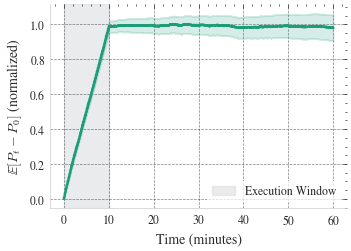

In [9]:
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    x = np.array(df_impact["timestamp"]) / (int(1e9) * 60)
    T = 10.0
    
    y_no = np.array(df_no_impact["avg_mid_price_change"])
    se_no = np.array(df_no_impact["mid_price_change_se"])
    
    ax.axvspan(0, T, color="#D5D8DC", alpha=0.5, label="Execution Window", zorder=0)
    
    ax.fill_between(
        x, y_no - 1.96 * se_no, y_no + 1.96 * se_no, alpha=0.18, color="#1B9E77"
    )
    ax.plot(x, y_no, linewidth=1.8, color="#1B9E77")
    
    ax.set_xlabel("Time (minutes)", fontsize=10)
    ax.set_ylabel(r"$\mathbb{E}[P_t - P_0]$ (normalized)", fontsize=10)
    ax.tick_params(labelsize=8.5)
    ax.legend(fontsize=8.5, framealpha=0.7, edgecolor="none", loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout(pad=0.3)
    # fig.savefig("../../paper/no_impact_metaorder_PFE.pdf", bbox_inches="tight")
    plt.show()

/tmp/ipykernel_3370918/2261647559.py:42: RuntimeWarning: invalid value encountered in sqrt
  peak_val * (np.sqrt(1 + h) - np.sqrt(h)),  # sqrt decay


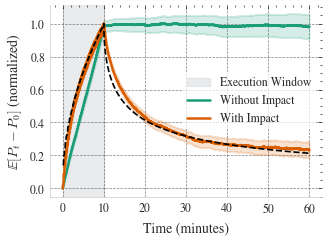

In [10]:
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    fig.patch.set_alpha(0)

    x = np.array(df_impact["timestamp"]) / (int(1e9) * 60)
    T = 10.0

    y_no = np.array(df_no_impact["avg_mid_price_change"])
    se_no = np.array(df_no_impact["mid_price_change_se"])
    y_im = np.array(df_impact["avg_mid_price_change"])
    se_im = np.array(df_impact["mid_price_change_se"])

    # execution window
    ax.axvspan(0, T, color="#D5D8DC", alpha=0.5, label="Execution Window", zorder=0)

    # no-impact series
    ax.fill_between(
        x, y_no - 1.96 * se_no, y_no + 1.96 * se_no, alpha=0.18, color="#1B9E77"
    )
    ax.plot(x, y_no, linewidth=1.8, color="#1B9E77", label="Without Impact")

    # impact series
    ax.fill_between(
        x, y_im - 1.96 * se_im, y_im + 1.96 * se_im, alpha=0.18, color="#D95F02"
    )
    ax.plot(x, y_im, linewidth=1.8, color="#D95F02", label="With Impact")

    # sqrt(Q) during execution + sqrt(1+h)-sqrt(h) decay after
    peak_idx = np.argmin(np.abs(x - T))
    peak_val = y_im[peak_idx]

    meta_vol = np.array(df_no_impact["avg_meta_vol"])
    meta_vol_at_peak = meta_vol[peak_idx]

    sqrt_vol = np.sqrt(meta_vol)
    sqrt_vol_at_peak = np.sqrt(meta_vol_at_peak)

    h = (x - T) / T
    sqrt_curve = np.where(
        x <= T,
        peak_val * sqrt_vol / sqrt_vol_at_peak,  # sqrt(Q) rise
        peak_val * (np.sqrt(1 + h) - np.sqrt(h)),  # sqrt decay
    )
    ax.plot(
        x,
        sqrt_curve,
        linewidth=1.2,
        color="black",
        ls="--",
    )

    ax.set_xlabel("Time (minutes)", fontsize=10)
    ax.set_ylabel(r"$\mathbb{E}[P_t - P_0]$ (normalized)", fontsize=10)
    ax.tick_params(labelsize=8.5)
    ax.legend(fontsize=8.5, framealpha=0.7, edgecolor="none", loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.savefig("../../paper/impact_PFE.pdf", bbox_inches="tight")
    plt.show()

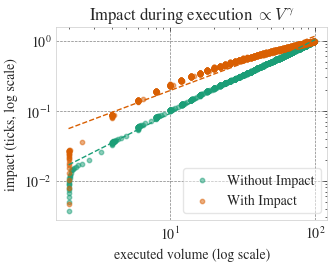

In [11]:
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    fig.patch.set_alpha(0)

    warmup_ns = int(1e9) * 60 * 10
    exec_df_no_impact = df_no_impact.filter(pl.col("timestamp").le(warmup_ns))
    exec_df_impact = df_impact.filter(pl.col("timestamp").le(warmup_ns))

    t_exec_no_impact = exec_df_no_impact["avg_meta_vol"].to_numpy()
    impact_exec_no_impact = exec_df_no_impact["avg_mid_price_change"].to_numpy()

    # Filter positive values for log-log

    pos_mask_no_impact = (t_exec_no_impact > 0) & (impact_exec_no_impact > 0)
    t_pos_no_impact = t_exec_no_impact[pos_mask_no_impact]
    impact_pos_no_impact = impact_exec_no_impact[pos_mask_no_impact]

    log_t_no_impact = np.log(t_pos_no_impact)
    log_impact_no_impact = np.log(impact_pos_no_impact)

    A = np.vstack([log_t_no_impact, np.ones(len(log_t_no_impact))]).T
    delta, c = np.linalg.lstsq(A, log_impact_no_impact, rcond=None)[0]

    t_fit_no_impact = np.linspace(t_pos_no_impact.min(), t_pos_no_impact.max(), 100)
    impact_fit_no_impact = np.exp(c) * t_fit_no_impact**delta

    ax.scatter(
        t_pos_no_impact,
        impact_pos_no_impact,
        alpha=0.5,
        s=10,
        label=rf"Without Impact",
        color="#1B9E77",
    )
    ax.plot(t_fit_no_impact, impact_fit_no_impact, "--", linewidth=1, color="#1B9E77")

    t_exec_impact = exec_df_impact["avg_meta_vol"].to_numpy()
    impact_exec_impact = exec_df_impact["avg_mid_price_change"].to_numpy()

    # Filter positive values for log-log
    pos_mask_impact = (t_exec_impact > 0) & (impact_exec_impact > 0)
    t_pos_impact = t_exec_impact[pos_mask_impact]
    impact_pos_impact = impact_exec_impact[pos_mask_impact]

    log_t_impact = np.log(t_pos_impact)
    log_impact_impact = np.log(impact_pos_impact)

    A = np.vstack([log_t_impact, np.ones(len(log_t_impact))]).T
    delta, c = np.linalg.lstsq(A, log_impact_impact, rcond=None)[0]

    t_fit_impact = np.linspace(t_pos_impact.min(), t_pos_impact.max(), 100)
    impact_fit_impact = np.exp(c) * t_fit_impact**delta

    ax.scatter(
        t_pos_impact,
        impact_pos_impact,
        alpha=0.5,
        s=10,
        label=rf"With Impact",
        color="#D95F02",
    )
    ax.plot(t_fit_impact, impact_fit_impact, "--", linewidth=1, color="#D95F02")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("executed volume (log scale)")
    ax.set_ylabel("impact (ticks, log scale)")
    ax.legend(framealpha=0.5)
    ax.set_title(r"Impact during execution $\propto V^\gamma$")
    fig.savefig("../../paper/impact_slope_PFE.pdf", bbox_inches="tight")

    plt.show()